In [1]:
import yfinance as yf 
from datetime import datetime 
import plotly.graph_objects as go 

In [ ]:
today_date = datetime.today().strftime('%Y-%m-%d')
print(today_date)
data = yf.download("MSFT",start="2022-01-01",end=today_date)
data.tail()

2026-02-16


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2026-02-09,413.600006,414.890015,400.869995,404.850006,45480500
2026-02-10,413.269989,423.679993,412.700012,419.619995,44857900
2026-02-11,404.369995,416.459991,401.010010,416.179993,42491000
2026-02-12,401.839996,406.200012,398.010010,405.000000,40802400
2026-02-13,401.320007,405.540009,398.049988,404.450012,34041200


In [8]:
data.columns

MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])

In [7]:
fig = go.Figure(data=go.Scatter(x=data.index,y=data[('Close','MSFT')],mode='lines'))

fig.show()

In [ ]:
from plotly.subplots import make_subplots

fig2 = make_subplots(specs=[[{"secondary_y":True}]])
fig2.add_trace(go.Scatter(x=data.index,y=data[('Close','MSFT')],name='Price'),secondary_y=False)
fig2.add_trace(go.Bar(x=data.index,y=data[('Volume','MSFT')],name='Volume',opacity=1),secondary_y=True)
fig2.update_yaxes(range=[0,500000000],secondary_y=True,visible=True)
fig2.update_yaxes(secondary_y=True,visible=True)
fig2.show()

In [18]:
fig3 = make_subplots(specs=[[{"secondary_y":True}]])
fig3.add_trace(go.Candlestick(x=data.index,
                              open=data[('Open','MSFT')],
                              high=data[('High','MSFT')],
                              low=data[('Low','MSFT')],
                              close=data[('Close','MSFT')]
                              ))
fig3.show()

In [1]:
import pandas as pd 
import yfinance as yf 
import matplotlib.pyplot as plt 
#plt.style.use('seaborn-v0_8-darkgrid')

In [ ]:

futures_data = yf.download("PL=F",start="2022-01-01",end="2026-02-22")
futures_data.index = pd.to_datetime(futures_data.index)
futures_data.columns

[*********************100%***********************]  1 of 1 completed


MultiIndex([( 'Close', 'PL=F'),
            (  'High', 'PL=F'),
            (   'Low', 'PL=F'),
            (  'Open', 'PL=F'),
            ('Volume', 'PL=F')],
           names=['Price', 'Ticker'])

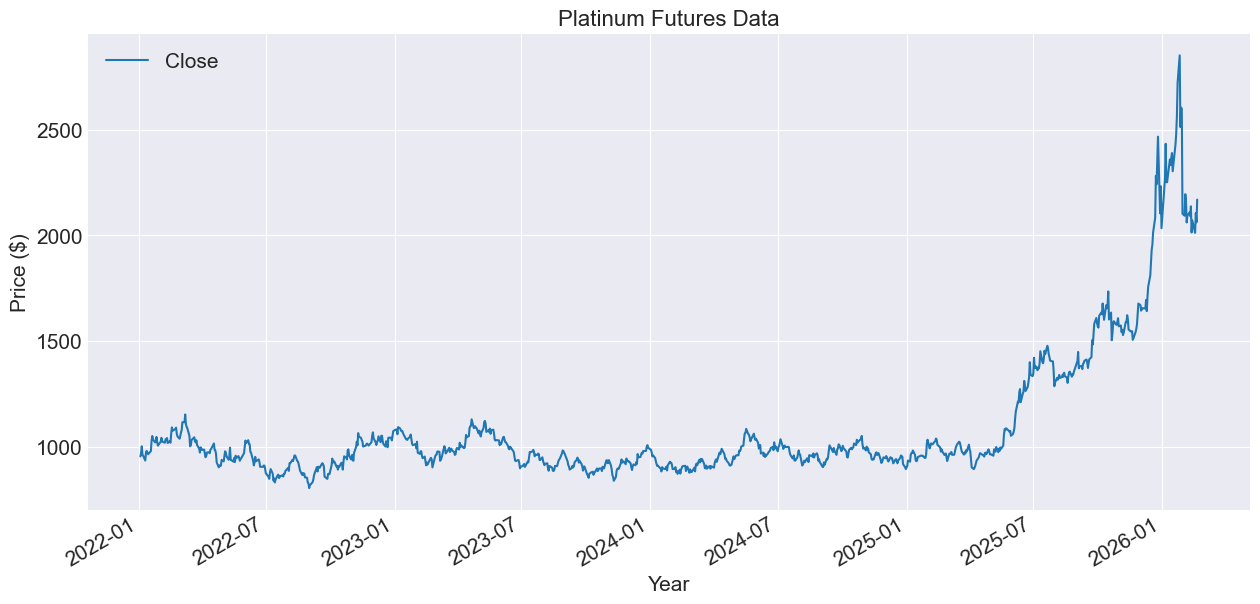

In [3]:
plt.figure(figsize=(15,7))
futures_data[('Close','PL=F')].plot()

plt.title('Platinum Futures Data',fontsize=16)
plt.xlabel('Year',fontsize=15)
plt.ylabel('Price ($)',fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(['Close'],prop={'size':15})
plt.show()

In [8]:
futures_data = yf.download(["GC=F","HG=F"],
                           start="2010-01-01",
                           end="2026-02-02",
                           group_by='tickers')
futures_data.index = pd.to_datetime(futures_data.index)
futures_data.tail()

[*********************100%***********************]  2 of 2 completed


Ticker        HG=F                                        GC=F               \
Price         Open    High     Low   Close Volume         Open         High   
Date                                                                          
2026-01-26  5.9800  5.9890  5.8785  5.9840    720  5081.500000  5095.600098   
2026-01-27  5.8320  5.8410  5.8205  5.8285    917  5079.899902  5079.899902   
2026-01-28  5.8815  5.8945  5.8815  5.8925   1681  5301.600098  5301.600098   
2026-01-29  6.1570  6.5080  6.1315  6.1755   3804  5415.700195  5586.200195   
2026-01-30  6.1545  6.1545  5.7460  5.8970   1981  5376.399902  5440.500000   

Ticker                                          
Price               Low        Close    Volume  
Date                                            
2026-01-26  5052.200195  5079.700195     180.0  
2026-01-27  5079.899902  5079.899902      34.0  
2026-01-28  5301.600098  5301.600098  112054.0  
2026-01-29  5097.500000  5318.399902   23709.0  
2026-01-30  4700.000000  4713.899902    8374.0

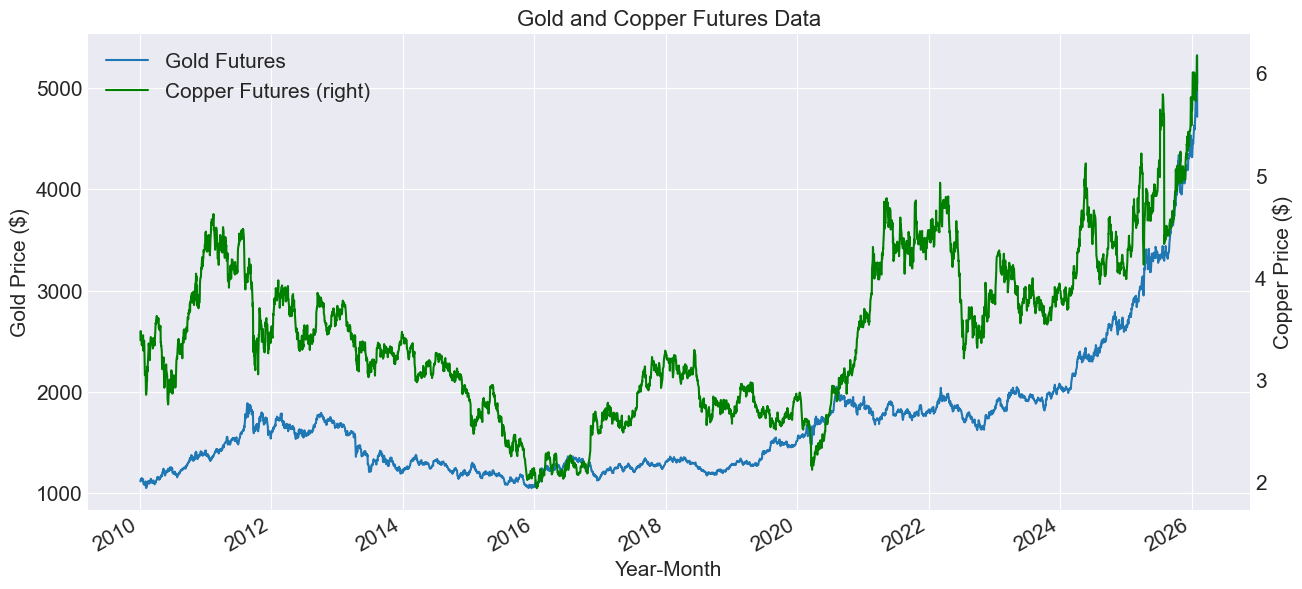

In [9]:
ax = plt.figure(figsize=(15,7))
ax = futures_data['GC=F']['Close'].plot(label='Gold Futures')
ax2 = futures_data['HG=F']['Close'].plot(secondary_y=True,
                                         color='g',
                                         ax=ax,
                                         label='Copper Futures')
plt.title('Gold and Copper Futures Data',fontsize=16)
ax.set_xlabel('Year-Month',fontsize=15)
ax.set_ylabel('Gold Price ($)',fontsize=15)
ax2.set_ylabel('Copper Price ($)',fontsize=15)
ax.tick_params(axis='both',labelsize=15)
ax2.tick_params(axis='y',labelsize=15)
h1,l1=ax.get_legend_handles_labels()
h2,l2=ax2.get_legend_handles_labels()
ax.legend(h1+h2,l1+l2,loc=2,prop={'size':15})
plt.show()

In [10]:
futures_symbol = "ES=F"
futures_symbol = "3067.HK"
futures_data = yf.download(futures_symbol,
                           start="2025-11-01",
                           end="2026-02-22",
                           interval="1d")



[*********************100%***********************]  1 of 1 completed


In [12]:
import ta 
# Calculate RSI 
futures_data["RSI"] = ta.momentum.RSIIndicator(futures_data[("Close",futures_symbol)]).rsi()

# Calculate Bollinger Bands
bbands = ta.volatility.BollingerBands(futures_data[("Close",futures_symbol)])
futures_data["BB_upper"] = bbands.bollinger_hband()
futures_data["BB_lower"] = bbands.bollinger_lband()

# Calculate MACD 
macd = ta.trend.MACD(futures_data[("Close",futures_symbol)])
futures_data["MACD"] = macd.macd()
futures_data["MACD_signal"] = macd.macd_signal()

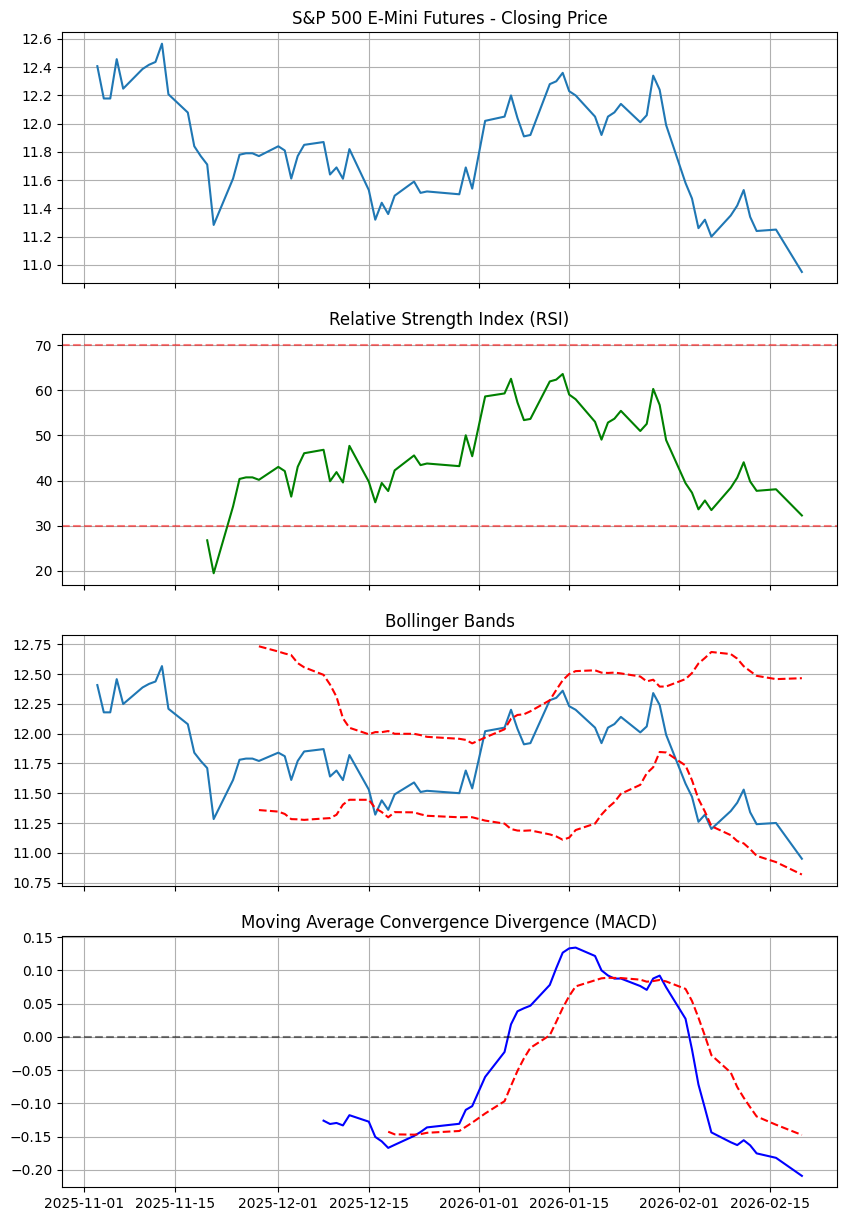

In [13]:
fig,axes = plt.subplots(4,1,figsize=(10,15),sharex=True)
axes[0].plot(futures_data.index,futures_data[("Close",futures_symbol)])
axes[0].set_title("S&P 500 E-Mini Futures - Closing Price")
axes[0].grid()

axes[1].plot(futures_data.index, futures_data["RSI"], label="RSI", color="g")
axes[1].axhline(30, linestyle="--", color="r", alpha=0.5)
axes[1].axhline(70, linestyle="--", color="r", alpha=0.5)
axes[1].set_title("Relative Strength Index (RSI)")
axes[1].grid()

axes[2].plot(futures_data.index,futures_data[("Close",futures_symbol)],label="Close")
axes[2].plot(futures_data.index,futures_data["BB_upper"],label="Upper Bollinger Band",
             linestyle="--",color="r")
axes[2].plot(futures_data.index,futures_data["BB_lower"],label="Lower Bollinger Band",
             linestyle="--",color="r")
axes[2].set_title("Bollinger Bands")
axes[2].grid()

axes[3].plot(futures_data.index, futures_data["MACD"],label="MACD",color="b")
axes[3].plot(futures_data.index, futures_data["MACD_signal"],label="Signal Line",linestyle="--",color="r")
axes[3].axhline(0,linestyle="--",color="k",alpha=0.5)
axes[3].set_title("Moving Average Convergence Divergence (MACD)")
axes[3].grid()